In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import random
from scipy.stats import pearsonr, spearmanr
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.offsetbox as offsetbox # for text box with position control
import pickle
import copy
import sys
from sklearn.linear_model import LinearRegression

In [2]:
def dissectSeq(sq):
    aaList = []
    counter = 0
    for a in sq:
        aaList.append(str(counter)+a)
        counter+=1
    return ':'.join(aaList)

def containsMutations(genotype):
    return genotype.split(':')

def makeBinary(unique_mutations, genotype):
    genotypeList = containsMutations(genotype)
    indexList = []
    
    for i in range(len(genotypeList)):
        indexList.append(unique_mutations.index(genotypeList[i]))
    
    line = np.zeros((1,len(unique_mutations)))
    line[:,indexList] = 1.
    
    return line

def read_data_all_positions(input_file):
    
    data = pd.read_table(input_file,
                         dtype = {"aa_seq" : object})
    data.columns = ['fitness', 'aa_seq']
    
    genotypeList = [dissectSeq(sq) for sq in data.aa_seq]
    mutation_list = pd.Series(genotypeList)
    
    unique_mutations = set(':'.join(mutation_list).split(':'))
    unique_mutations = sorted(list(unique_mutations))
    
    if '' in unique_mutations:
        unique_mutations.remove('')

    nn_genotypes_values = np.zeros((len(data), len(unique_mutations)))
    nn_fitness_values = data.fitness.values
    aa_seq = data.aa_seq
    
    for i in range(len(mutation_list)):
        if mutation_list[i] != '':
            nn_genotypes_values[i] = makeBinary(unique_mutations, mutation_list[i])[0]
    
    return nn_genotypes_values, nn_fitness_values, unique_mutations, aa_seq, mutation_list

In [3]:
# file name
dataset_filename = "data/S7.txt"

# read data
feature_matrix, observed_fitness, unique_mutations, aa_sequences, sequence_ids = read_data_all_positions(dataset_filename)

In [4]:
X = feature_matrix
y = observed_fitness
model = LinearRegression()
model.fit(X, y)

LinearRegression(copy_X=True, fit_intercept=True, n_jobs=None, normalize=False)

In [5]:
y_pred = model.predict(X)

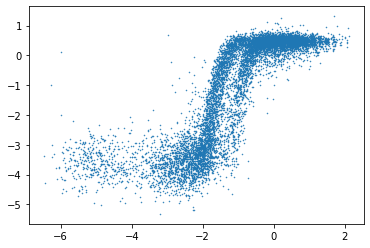

In [6]:
plt.plot(y_pred, y, "o", ms = 0.5)

In [7]:
dataframe_to_export = pd.DataFrame({"seq" : aa_sequences,
                                    "observed_fitness" : observed_fitness,
                                    "predicted_fitness" : y_pred})
dataframe_to_export.to_csv("002_LM_Predictions.txt",
                           sep = "\t",
                           index = False)